In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import pandas as pd

In [3]:
DATASET_PATH = "../Data/Sample_Data"

CLASSES = ["Contemporary", "Kandyan", "HipHop"]

Load Video Paths & Labels

In [4]:
video_paths = []
labels = []

for label, class_name in enumerate(CLASSES):
    class_folder = os.path.join(DATASET_PATH, class_name)
    
    for video_file in os.listdir(class_folder):
        if video_file.endswith((".mp4", ".avi", ".mov")):
            video_paths.append(os.path.join(class_folder, video_file))
            labels.append(class_name)

print(f"Total videos: {len(video_paths)}")

Total videos: 38


In [5]:
label_counts = Counter(labels)

label_counts

Counter({'HipHop': 15, 'Contemporary': 12, 'Kandyan': 11})

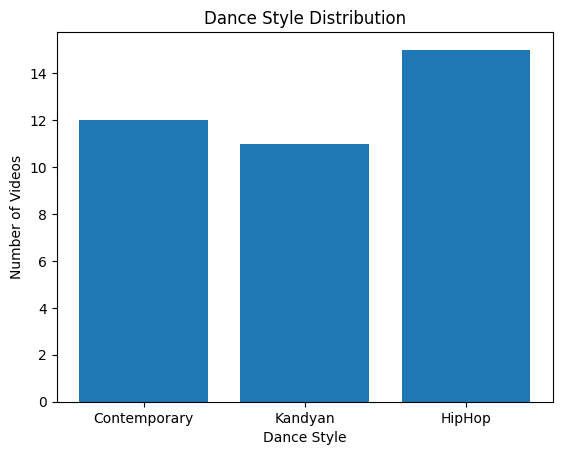

In [6]:
plt.bar(label_counts.keys(), label_counts.values())
plt.title("Dance Style Distribution")
plt.xlabel("Dance Style")
plt.ylabel("Number of Videos")
plt.show()

In [7]:
def get_video_info(video_path):
    cap = cv2.VideoCapture(video_path)
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = frame_count / fps if fps > 0 else 0
    
    cap.release()
    
    return fps, frame_count, duration

In [8]:
for i in range(3):
    fps, frames, duration = get_video_info(video_paths[i])
    print(f"Video: {os.path.basename(video_paths[i])}")
    print(f"FPS: {fps:.2f}, Frames: {frames}, Duration: {duration:.2f}s\n")

Video: C1.mp4
FPS: 25.00, Frames: 2140, Duration: 85.60s

Video: C10.mp4
FPS: 29.00, Frames: 298, Duration: 10.27s

Video: C11.mp4
FPS: 30.00, Frames: 6009, Duration: 200.30s



In [9]:
def show_sample_frames(video_path, num_frames=5):
    cap = cv2.VideoCapture(video_path)
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    
    frames = []
    
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    
    cap.release()
    
    plt.figure(figsize=(15, 3))
    for i, frame in enumerate(frames):
        plt.subplot(1, num_frames, i + 1)
        plt.imshow(frame)
        plt.axis("off")
    plt.show()

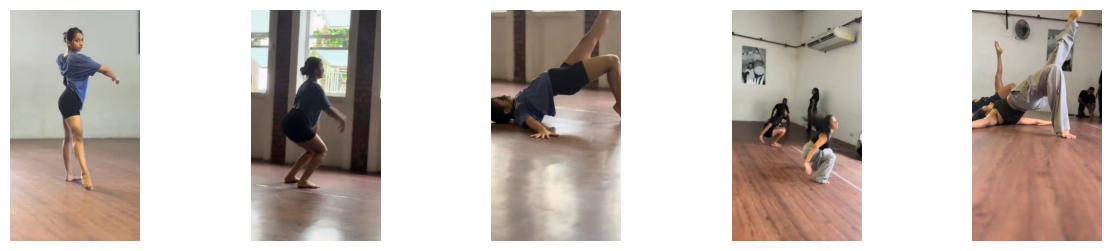

In [10]:
show_sample_frames(video_paths[5])

In [11]:
def get_frame_shape(video_path):
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()
    
    if ret:
        return frame.shape
    return None

shapes = [get_frame_shape(v) for v in video_paths[:10]]
shapes

[(720, 1280, 3),
 (850, 478, 3),
 (576, 1052, 3),
 (1024, 576, 3),
 (1024, 576, 3),
 (1024, 576, 3),
 (850, 478, 3),
 (1024, 576, 3),
 (850, 478, 3),
 (1024, 576, 3)]

In [12]:
data_info = []

for path, label in zip(video_paths, labels):
    fps, frames, duration = get_video_info(path)
    data_info.append({
        "video": os.path.basename(path),
        "label": label,
        "fps": fps,
        "frames": frames,
        "duration_sec": duration
    })

df = pd.DataFrame(data_info)
df.head()

,video,label,fps,frames,duration_sec
0,C1.mp4,Contemporary,25.000000,2140,85.600000
1,C10.mp4,Contemporary,29.004189,298,10.274378
2,C11.mp4,Contemporary,30.000000,6009,200.300000
3,C12.mp4,Contemporary,30.000000,1301,43.366667
4,C2.mp4,Contemporary,30.000000,1314,43.800000


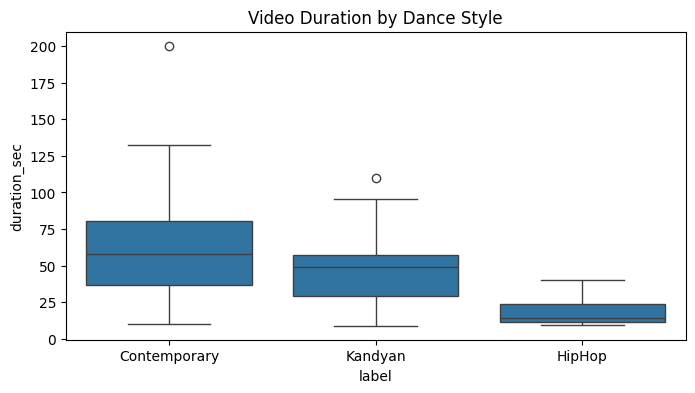

In [13]:
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="label", y="duration_sec")
plt.title("Video Duration by Dance Style")
plt.show()

Label Encoding

In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

label_map = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
label_map

{np.str_('Contemporary'): 0, np.str_('HipHop'): 1, np.str_('Kandyan'): 2}

In [15]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    video_paths,
    encoded_labels,
    test_size=0.15,
    stratify=encoded_labels,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.176,  # keeps val ≈15%
    stratify=y_temp,
    random_state=42
)

In [16]:
IMG_SIZE = 224
NUM_FRAMES = 30

In [17]:
def extract_frames(video_path, num_frames=30, img_size=224):
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames > 0:
        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
        index_set = set(indices)
        current = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if current in index_set:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (img_size, img_size))
                frame = frame.astype(np.float32) / 255.0
                frames.append(frame)

            current += 1

    else:
        skip = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if skip % 10 == 0:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (img_size, img_size))
                frame = frame.astype(np.float32) / 255.0
                frames.append(frame)

            skip += 1
            if len(frames) >= num_frames:
                break

    cap.release()

    if len(frames) == 0:
        return None

    while len(frames) < num_frames:
        frames.append(frames[-1])

    return np.stack(frames[:num_frames], axis=0)

In [18]:
for style in ["HipHop", "Contemporary", "Kandyan"]:
    idx = labels.index(style)
    frames = extract_frames(video_paths[idx])
    print(style, frames.shape)

HipHop (30, 224, 224, 3)
Contemporary (30, 224, 224, 3)
Kandyan (30, 224, 224, 3)


In [19]:
os.makedirs("preprocessed/train", exist_ok=True)
os.makedirs("preprocessed/val", exist_ok=True)
os.makedirs("preprocessed/test", exist_ok=True)

In [20]:
def preprocess_and_save(video_list, labels_list, split_name):
    X_paths = []
    y = []

    for i, (video, label) in enumerate(zip(video_list, labels_list)):
        frames = extract_frames(video)
        if frames is None:
            continue

        save_path = f"preprocessed/{split_name}/video_{i}.npy"
        np.save(save_path, frames)

        X_paths.append(save_path)
        y.append(label)

    return X_paths, np.array(y)

In [21]:
X_train_paths, y_train_p = preprocess_and_save(X_train, y_train, "train")
X_val_paths, y_val_p     = preprocess_and_save(X_val, y_val, "val")
X_test_paths, y_test_p   = preprocess_and_save(X_test, y_test, "test")

In [22]:
import numpy as np
import tensorflow as tf
from keras.utils import Sequence

In [23]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Dropout, TimeDistributed, GlobalAveragePooling2D
from keras.applications import MobileNetV2
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [24]:
class VideoDataGenerator(Sequence):
    def __init__(self, video_paths, labels, batch_size=2, shuffle=True):
        self.video_paths = video_paths
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.video_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.video_paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        
        X_batch = []
        y_batch = []

        for i in batch_indices:
            video = np.load(self.video_paths[i])  # (30, 224, 224, 3)
            X_batch.append(video)
            y_batch.append(self.labels[i])

        return np.array(X_batch), np.array(y_batch)


In [25]:
BATCH_SIZE = 2

train_gen = VideoDataGenerator(X_train_paths, y_train_p, batch_size=BATCH_SIZE)
val_gen   = VideoDataGenerator(X_val_paths, y_val_p, batch_size=BATCH_SIZE, shuffle=False)
test_gen  = VideoDataGenerator(X_test_paths, y_test_p, batch_size=BATCH_SIZE, shuffle=False)


In [26]:
cnn_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

cnn_base.trainable = False

In [27]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

In [28]:
NUM_FRAMES = 30
NUM_CLASSES = 3

video_input = Input(shape=(NUM_FRAMES, 224, 224, 3))

x = TimeDistributed(cnn_base)(video_input)
x = TimeDistributed(GlobalAveragePooling2D())(x)

x = LSTM(128, return_sequences=False)(x)
x = Dropout(0.5)(x)

output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(video_input, output)

In [29]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 7, 7, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979,779 (11.37 MB)

 Trainable params: 721,795 (2.75 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [32]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),
    ModelCheckpoint(
        "best_dance_model.h5",
        monitor="val_loss",
        save_best_only=True
    )
]

In [33]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_p),
    y=y_train_p
)

class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(1.0833333333333333),
 1: np.float64(0.7878787878787878),
 2: np.float64(1.2380952380952381)}

In [34]:
EPOCHS = 30

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

c:\Users\HP\anaconda3\envs\ml-tf\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2198 - loss: 1.2718

13/13 ━━━━━━━━━━━━━━━━━━━━ 192s 5s/step - accuracy: 0.3077 - loss: 1.1331 - val_accuracy: 0.1667 - val_loss: 1.1453 - learning_rate: 1.0000e-04
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4064 - loss: 1.0575

13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.4615 - loss: 0.9495 - val_accuracy: 0.1667 - val_loss: 1.1279 - learning_rate: 1.0000e-04
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7814 - loss: 0.7038

13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.8077 - loss: 0.6586 - val_accuracy: 0.1667 - val_loss: 1.1190 - learning_rate: 1.0000e-04
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.8846 - loss: 0.5849 - val_accuracy: 0.3333 - val_loss: 1.2073 - learning_rate: 1.0000e-04
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9231 - loss: 0.4562 - val_accuracy: 0.5000 - val_loss: 1.1681 - learning_rate: 1.0000e-04
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9938 - loss: 0.3884
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9615 - loss: 0.3512 - val_accuracy: 0.3333 - val_loss: 1.2371 - learning_rate: 1.0000e-04
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 1.0000 - loss: 0.3168 - val_accuracy: 0.3333 - val_loss: 1.2419 - learning_rate: 5.0000e-05
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9231 - loss: 0.2947 - val_acc

In [35]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6667 - loss: 0.7979
Test Accuracy: 0.67


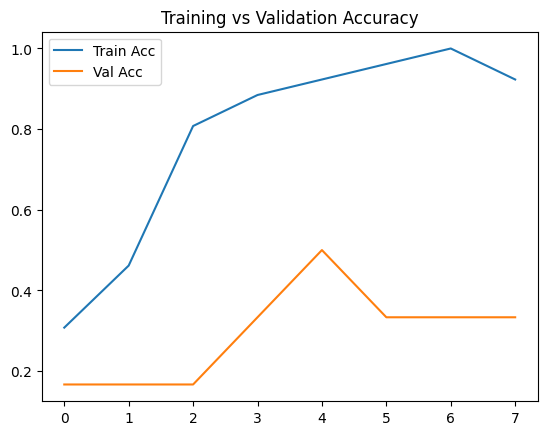

In [36]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [38]:
model.export("dance_style_model")

INFO:tensorflow:Assets written to: dance_style_model\assets


INFO:tensorflow:Assets written to: dance_style_model\assets


Saved artifact at 'dance_style_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2491976675776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2491976753648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2491976754352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2491976752416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2491976754000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2491847092960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2491976757872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2491976759280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2491976760512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2491977090144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2491977093312: TensorSpec

In [39]:
model.save("dance_style_model.keras")